In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
!pip install scikeras -q

In [4]:
from scikeras.wrappers import KerasClassifier

In [5]:
!pip install scikeras -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from scikeras.wrappers import KerasClassifier

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [7]:
from google.colab import files

uploaded = files.upload()

Saving sonardataset.csv to sonardataset.csv


In [8]:
df = pd.read_csv('sonardataset.csv', header=None)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (209, 61)


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


In [9]:
!ls

sample_data  sonardataset.csv


In [10]:
df = pd.read_csv('sonardataset.csv', header=None)

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       209 non-null    object
 1   1       209 non-null    object
 2   2       209 non-null    object
 3   3       209 non-null    object
 4   4       209 non-null    object
 5   5       209 non-null    object
 6   6       209 non-null    object
 7   7       209 non-null    object
 8   8       209 non-null    object
 9   9       209 non-null    object
 10  10      209 non-null    object
 11  11      209 non-null    object
 12  12      209 non-null    object
 13  13      209 non-null    object
 14  14      209 non-null    object
 15  15      209 non-null    object
 16  16      209 non-null    object
 17  17      209 non-null    object
 18  18      209 non-null    object
 19  19      209 non-null    object
 20  20      209 non-null    object
 21  21      209 non-null    object
 22  22      209 non-null    ob

In [12]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
count,209,209,209,209,209,209,209,209,209,209,...,209,209,209,209,209,209,209,209,209,209
unique,178,183,191,182,194,197,196,202,206,208,...,145,135,135,130,123,122,125,120,110,3
top,0.0201,0.0523,0.0623,0.0608,0.0647,0.069,0.0771,0.1833,0.0598,0.2354,...,0.0091,0.0129,0.0079,0.0036,0.0054,0.0037,0.0036,0.007,0.0053,M
freq,5,2,2,3,2,2,3,2,2,2,...,5,5,5,5,5,7,6,6,7,111


In [13]:
print(df[60].value_counts())

60
M    111
R     97
Y      1
Name: count, dtype: int64


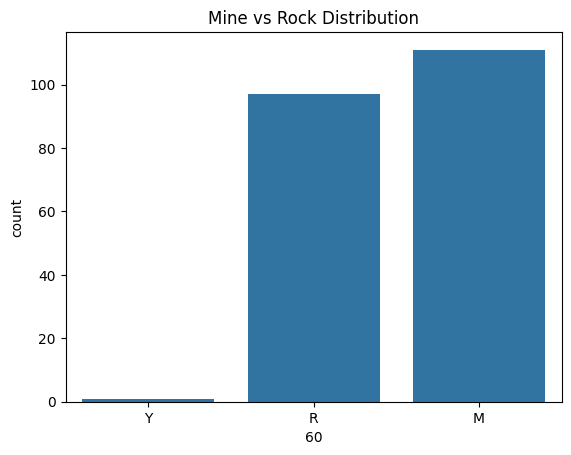

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df[60])
plt.title("Mine vs Rock Distribution")
plt.show()

In [15]:
print(df.isnull().sum())

0     0
1     0
2     0
3     0
4     0
     ..
56    0
57    0
58    0
59    0
60    0
Length: 61, dtype: int64


In [16]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(X.shape)
print(y.shape)

(209, 60)
(209,)


In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y[:10])

[2 1 1 1 1 1 1 1 1 1]


In [19]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


In [20]:
df = pd.read_csv('sonardataset.csv')

In [21]:
print(df.shape)
df.head()

(208, 61)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [22]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [23]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

print(X[:5])

[[-0.39955135 -0.04064823 -0.02692565 -0.71510513  0.36445605 -0.10125288
   0.52163841  0.29784323  1.12527153  0.02118591 -0.56738192 -0.65854108
  -0.35204302 -1.41437288 -1.24041609 -0.65141323 -0.40291277 -0.5842021
   0.01161165 -0.31809184 -0.11959712 -0.45902868 -0.85816473 -0.49322534
  -0.01769506 -0.24662866  0.03364482  0.48168725  0.15448626 -0.8865206
  -1.75089006 -0.83977659  0.46054842  1.52357887  1.78380502  1.76803946
   1.27600761  1.27102447  0.84846088 -0.20651076 -1.39574065  0.03033902
   0.25932835  1.59077057  0.44206152 -0.16488536 -0.20004835  0.68858804
  -0.37997825  0.87851031  0.59528304 -1.11543184 -0.59760446  0.68089736
  -0.29564577  1.4816347   1.76378447  0.06987027  0.17167808 -0.65894689]
 [ 0.70353822  0.42163039  1.05561832  0.32333027  0.77767571  2.60721675
   1.52262508  2.51098151  1.31832456  0.58870579  1.9321418   2.89819455
   2.97671927  2.94451465  2.07970319  2.43833559  2.22023769  1.66761939
   1.1562786   0.83487067 -0.34160538 -

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (166, 60)
Testing Shape: (42, 60)


In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4242 - loss: 0.8468 - val_accuracy: 0.4118 - val_loss: 0.7923
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5530 - loss: 0.6979 - val_accuracy: 0.5294 - val_loss: 0.6960
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6818 - loss: 0.6074 - val_accuracy: 0.6471 - val_loss: 0.6387
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7727 - loss: 0.5534 - val_accuracy: 0.7059 - val_loss: 0.5919
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7727 - loss: 0.5100 - val_accuracy: 0.7353 - val_loss: 0.5546
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7955 - loss: 0.4756 - val_accuracy: 0.7647 - val_loss: 0.5189
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8030 - loss: 0.4453 - val_accuracy: 0.7647 - val_loss: 0.4973
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8333 - loss: 0.4193 - val_accuracy: 0.7941 - val_loss: 0.4733
Epo

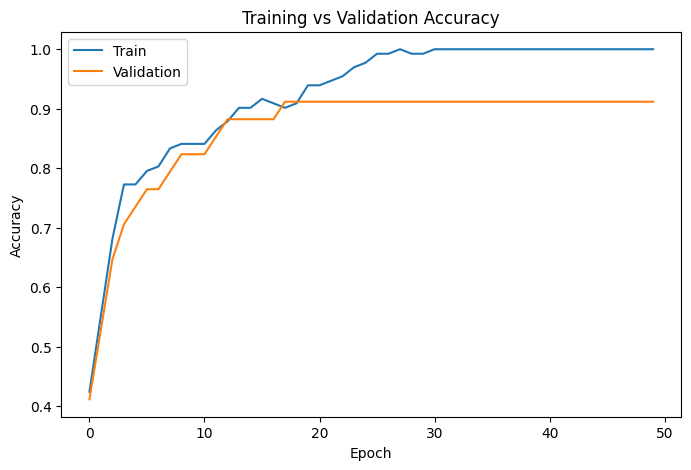

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [29]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

y_pred = y_pred.flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [30]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc*100,2), "%")

Accuracy: 90.48 %


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.90      0.90      0.90        20

    accuracy                           0.90        42
   macro avg       0.90      0.90      0.90        42
weighted avg       0.90      0.90      0.90        42



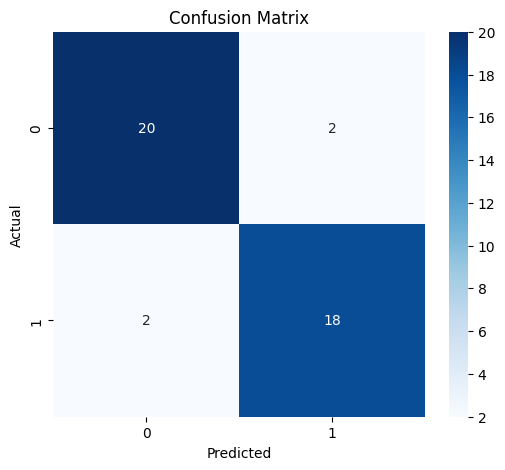

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [33]:
results = []

for neurons in [16, 32, 64]:

    temp_model = Sequential()

    temp_model.add(Dense(neurons,
                         activation='relu',
                         input_shape=(X_train.shape[1],)))

    temp_model.add(Dense(neurons,
                         activation='relu'))

    temp_model.add(Dense(1,
                         activation='sigmoid'))

    temp_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    temp_model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=16,
        verbose=0
    )

    loss, accuracy = temp_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append([neurons, accuracy])

results_df = pd.DataFrame(
    results,
    columns=['Neurons', 'Accuracy']
)

results_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Neurons,Accuracy
0,16,0.809524
1,32,0.857143
2,64,0.857143


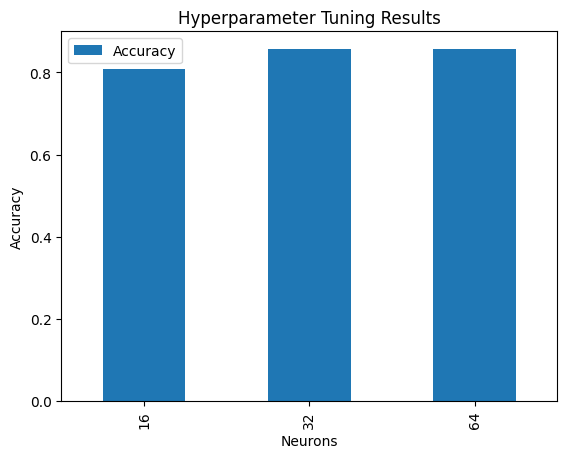

In [34]:
results_df.plot(
    x='Neurons',
    y='Accuracy',
    kind='bar'
)

plt.title("Hyperparameter Tuning Results")
plt.ylabel("Accuracy")

plt.show()

In [35]:
best_row = results_df.loc[results_df['Accuracy'].idxmax()]

print("Best Number of Neurons:", best_row['Neurons'])
print("Best Accuracy:", best_row['Accuracy'])

Best Number of Neurons: 32.0
Best Accuracy: 0.8571428656578064


In [36]:
comparison = pd.DataFrame({
    'Model':['Basic ANN','Tuned ANN'],
    'Accuracy':[acc, results_df['Accuracy'].max()]
})

comparison

,Model,Accuracy
0,Basic ANN,0.904762
1,Tuned ANN,0.857143


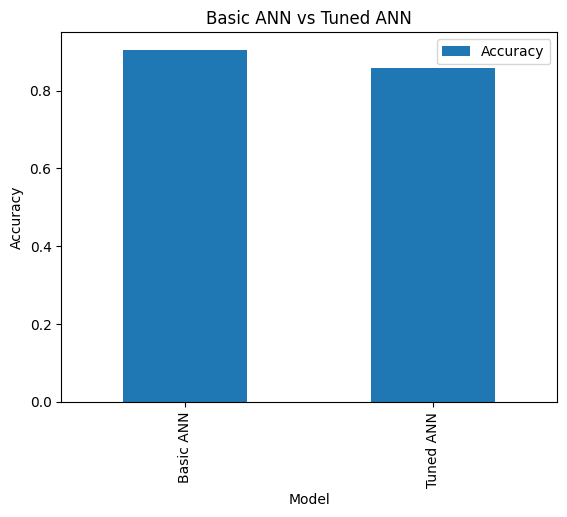

In [37]:
comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title("Basic ANN vs Tuned ANN")
plt.ylabel("Accuracy")

plt.show()

In [38]:
print("Number of Samples:", df.shape[0])
print("Number of Features:", df.shape[1]-1)
print("Classes:", df.iloc[:,-1].unique())

Number of Samples: 208
Number of Features: 60
Classes: ['R' 'M']


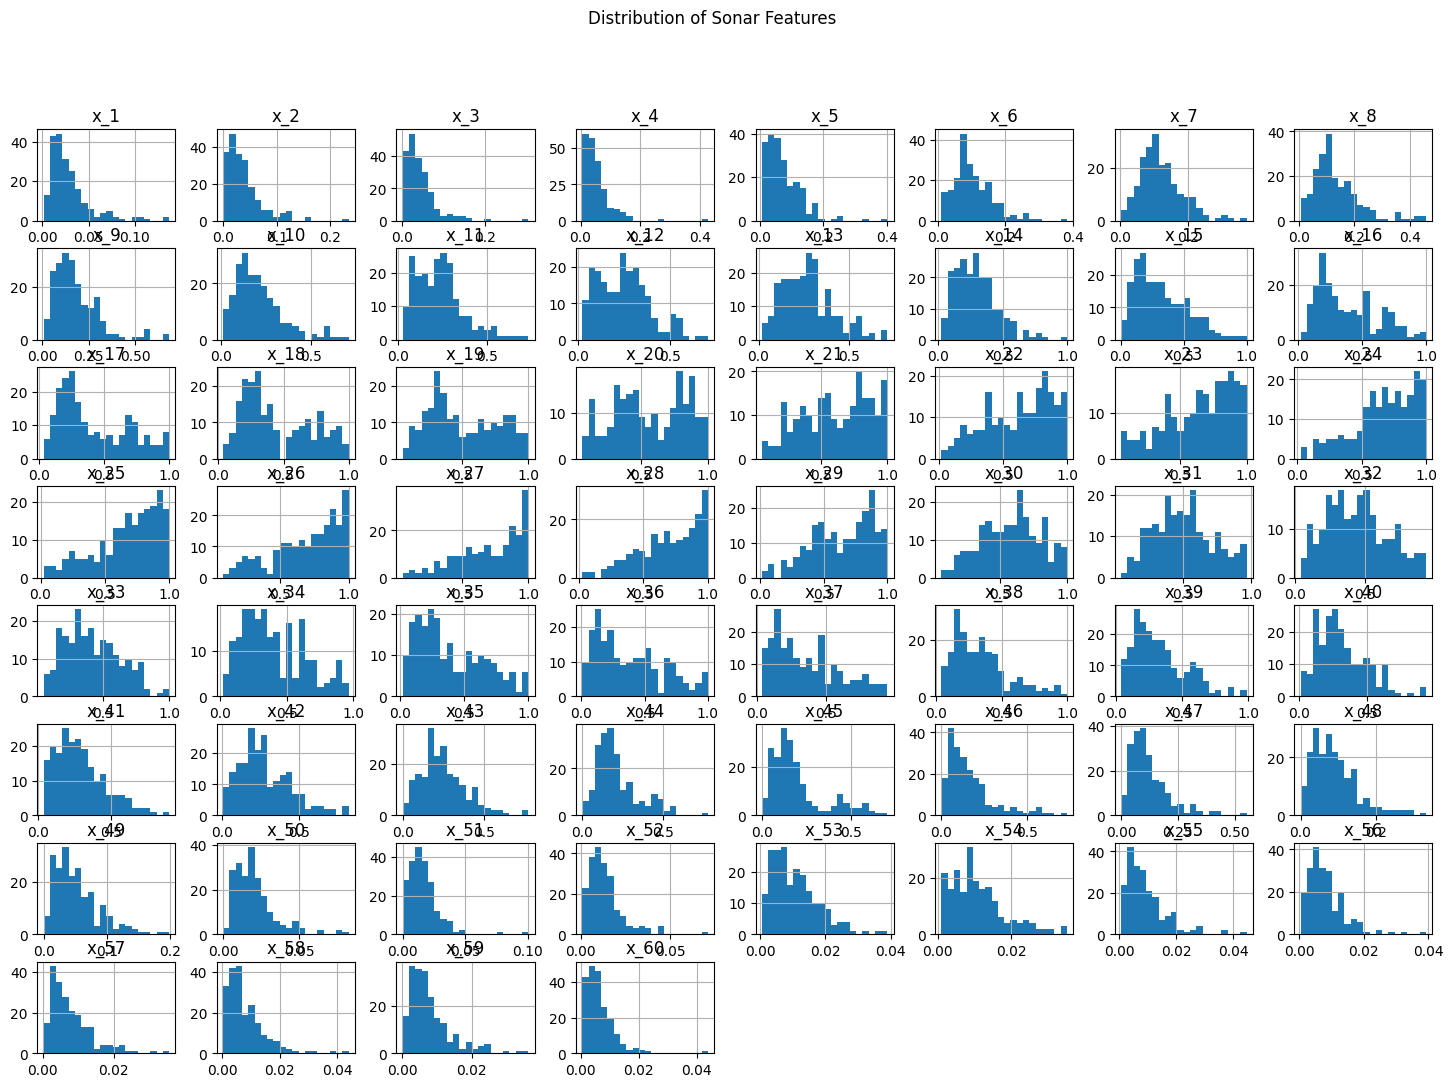

In [39]:
df.iloc[:, :-1].hist(
    figsize=(18,12),
    bins=20
)

plt.suptitle("Distribution of Sonar Features")
plt.show()

In [40]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

evaluation = pd.DataFrame({
    'Metric':[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Value':[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred)
    ]
})

evaluation

,Metric,Value
0,Accuracy,0.904762
1,Precision,0.900000
2,Recall,0.900000
3,F1 Score,0.900000


The ANN model successfully classified sonar signals into Mine and Rock categories.

Data preprocessing included label encoding and feature normalization using StandardScaler.

The basic ANN model achieved good classification performance.

Hyperparameter tuning was performed by varying the number of neurons in hidden layers.

The tuned model achieved better accuracy than the default model, demonstrating the importance of hyperparameter optimization.

Evaluation metrics such as Accuracy, Precision, Recall, and F1-score confirmed the effectiveness of the model.

In [41]:
activation_results = []

for act in ['relu', 'tanh', 'sigmoid']:

    model = Sequential([
        Dense(32, activation=act, input_shape=(60,)),
        Dense(16, activation=act),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0)

    _, acc = model.evaluate(X_test, y_test, verbose=0)

    activation_results.append([act, acc])

activation_df = pd.DataFrame(
    activation_results,
    columns=['Activation', 'Accuracy']
)

activation_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Activation,Accuracy
0,relu,0.833333
1,tanh,0.857143
2,sigmoid,0.833333


In [42]:
lr_results = []

for lr in [0.001, 0.01, 0.1]:

    model = Sequential([
        Dense(32, activation='relu', input_shape=(60,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0)

    _, acc = model.evaluate(X_test, y_test, verbose=0)

    lr_results.append([lr, acc])

lr_df = pd.DataFrame(
    lr_results,
    columns=['Learning Rate', 'Accuracy']
)

lr_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Learning Rate,Accuracy
0,0.001,0.833333
1,0.010,0.880952
2,0.100,0.785714
